# Attention Mechanism

## Start with the problem: a useful detail is somewhere in the history

Imagine reading a sequence of machine events. You are now predicting a fault, and one earlier maintenance event may matter much more than the routine readings around it. A recurrent model can carry a learned summary forward, but compressing every relevant detail into one state can make later retrieval difficult.

**Attention** gives a representation a content-dependent way to read from a collection of available representations. It compares what is being sought with descriptions of candidate positions, converts the matches into weights, and combines the content at those positions.

Attention can be used alongside recurrence or inside a Transformer. It does not require a language task: the positions might be sensor observations, image patches, or entries from another encoded sequence. The important contract is which representations are available to the read.

We will work from one scalar query to vector and matrix attention, then inspect masks, gradients, and practical limitations. The [code companion](26_Attention_Mechanism.ipynb) verifies the numerical reads and a causal-mask example. [Sequence Modeling](25_Sequence_Modeling_Notes.ipynb) explains why availability and target timing matter.


## Follow the read from matching to content

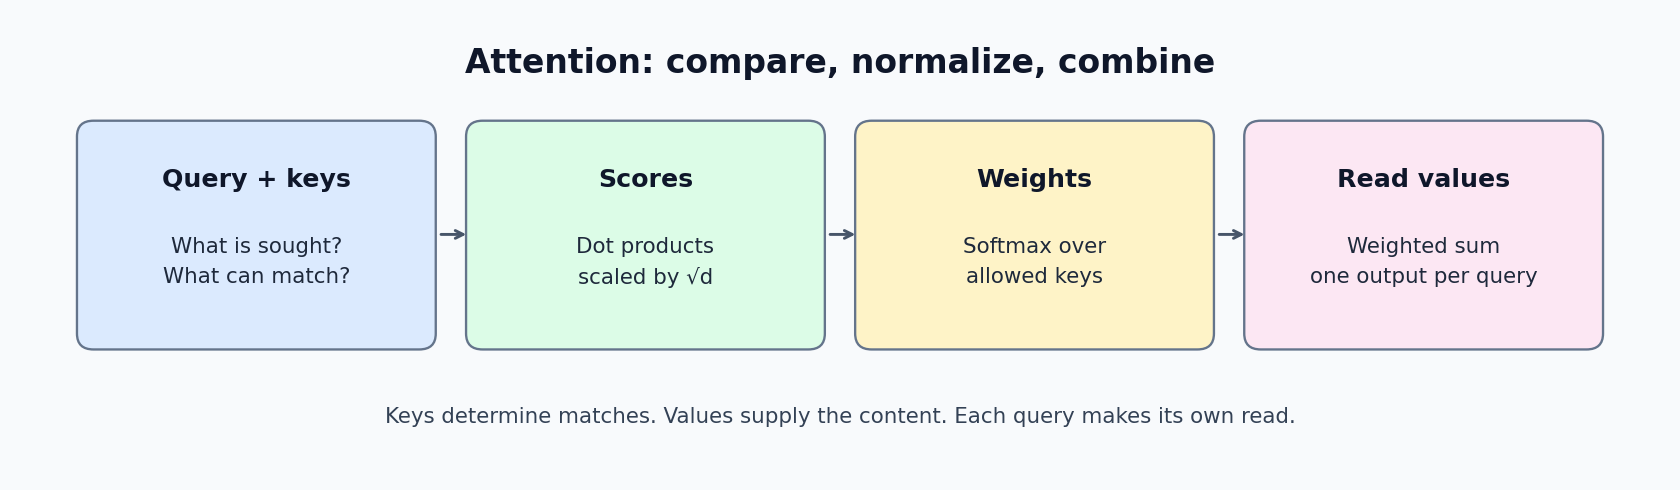

A **query** describes what the current position seeks. A **key** describes a candidate position for matching. A **value** supplies the content that position can contribute. These are learned vectors, not literal search questions or human-written labels.

| Component | Role | Useful question |
| --- | --- | --- |
| Query $q$ | Describes the read | What information would help this position? |
| Key $k_j$ | Participates in matching | How well does position $j$ match this query? |
| Value $v_j$ | Supplies content | What representation will be contributed? |
| Weight $\alpha_j$ | Controls contribution | How much of this value is included? |
| Output $o$ | Blended representation | What did this query read? |

Separating keys from values lets the matching description differ from the transmitted content. Every key must align with its value: key position $j$ describes the content at value position $j$.


## Build queries, keys, and values from representations

For a sequence matrix $X$ with $L$ positions and model width $D$, use learned projections:

$$Q=XW^Q,\qquad K=XW^K,\qquad V=XW^V.$$

If query/key width is $d_k$ and value width is $d_v$, then $W^Q,W^K$ have shape $D\times d_k$, while $W^V$ has shape $D\times d_v$. Biases can be added by the implementation. The projections can learn different feature combinations even though they start from the same $X$.

For a transparent identity-projection example, let two input rows be $[1,0]$ and $[0,1]$. With identity matrices, $Q=K=V=X$. The first query has a dot product of one with the first key and zero with the second. Real learned projections need not preserve that simple geometry.

The vectors are adjusted through the task loss. No training label needs to explicitly say “look at position three” for an attention layer to receive gradients. Conversely, the layer is not guaranteed to learn a particular retrieval strategy simply because we can describe one in words.


## Turn scores into a weighted read

For one query and several keys:

$$s_j=\frac{q\cdot k_j}{\sqrt{d_k}},$$
$$\alpha_j=\frac{e^{s_j}}{\sum_m e^{s_m}},\qquad o=\sum_j\alpha_jv_j.$$

The dot product sums coordinatewise matches. Dividing by $\sqrt{d_k}$ moderates the score scale as the query/key width grows. Softmax then normalizes across the allowed **key positions for this query**.

The weights are nonnegative and sum to one before attention dropout. The output is a weighted combination of value vectors. For scalar values, it lies between the smallest and largest allowed values. A later output projection or residual addition can change that bound.

To compute softmax stably, subtract the row's largest finite score before exponentiating. For $[1000,1001]$, calculating $e^{1000}$ directly is unsafe, but subtracting 1001 gives $[-1,0]$ and the same normalized weights. Adding the same constant to every score in a row does not change the distribution.


## Calculate the companion's scalar example completely

Take $q=1$, keys $[0,1]$, and values $[2,6]$. Here $d_k=1$, so scaling leaves the dot products unchanged.

| Calculation | First position | Second position |
| --- | --- | --- |
| Key | 0 | 1 |
| Score $qk_j$ | 0 | 1 |
| Exponential | 1 | $e\approx2.718282$ |
| Normalized weight | 0.268941 | 0.731059 |
| Weighted value | $0.268941(2)=0.537883$ | $0.731059(6)=4.386351$ |

Adding the contributions gives $o\approx4.924234$. The second position receives more weight because its score is higher, but the first still contributes. Attention is often a soft blend rather than a hard lookup.

Both positions could contain useful information. A large weight does not automatically indicate a semantically important word, and a small weight does not mean a position has no effect elsewhere in a multi-layer model. This example isolates the read, not a trained explanation of a decision.


## Change the query and watch the read change

Keep keys $[0,1]$ and values $[2,6]$, but change $q$:

| Query | Scores | Weights, rounded | Output |
| --- | --- | --- | --- |
| -1 | $[0,-1]$ | $[0.731059,0.268941]$ | 3.075766 |
| 0 | $[0,0]$ | $[0.5,0.5]$ | 4.000000 |
| 1 | $[0,1]$ | $[0.268941,0.731059]$ | 4.924234 |
| 2 | $[0,2]$ | $[0.119203,0.880797]$ | 5.523188 |

The same stored values can supply different outputs depending on the query. Query zero gives equal scores and therefore equal weights. Query two concentrates more weight on the second key, but still does not select it with probability exactly one.

These changes come from the dot-product geometry, not a universal rule that larger query coordinates are better. With negative or multidimensional keys, changing a query coordinate may increase some scores and decrease others.

If every key is identical, the query cannot distinguish positions through their key content. Position information or richer representations may be needed when the task requires order-specific retrieval.


## Work the vector example and include the scale

The companion also uses $q=[1,0]$, keys $k_1=[1,0]$, $k_2=[0,1]$, and values $v_1=[2,0]$, $v_2=[0,6]$. Now $d_k=2$.

The unscaled dot products are $[1,0]$, and the scaled scores are $[1/\sqrt2,0]\approx[0.707107,0]$. Softmax yields approximately $[0.669762,0.330238]$.

$$o=0.669762[2,0]+0.330238[0,6]\approx[1.339523,1.981431].$$

| Quantity | Shape | Meaning |
| --- | --- | --- |
| Query | $1\times2$ | One query with two coordinates |
| Keys | $2\times2$ | Two candidate keys |
| Scores and weights | $1\times2$ | One comparison per key |
| Values | $2\times2$ | Two content vectors |
| Output | $1\times2$ | One blended vector |

The value width happens to equal the key width here, but the operation permits a different $d_v$. Keys determine how many weights are needed; values determine how many output coordinates are produced.


## Compute many query reads with one matrix expression

For $L_q$ query positions and $L_k$ key/value positions:

$$S=\frac{QK^T}{\sqrt{d_k}},\qquad A=\operatorname{softmax}(S),\qquad O=AV.$$

| Matrix | Shape |
| --- | --- |
| $Q$ | $L_q\times d_k$ |
| $K$ | $L_k\times d_k$ |
| $V$ | $L_k\times d_v$ |
| $S,A$ | $L_q\times L_k$ |
| $O$ | $L_q\times d_v$ |

Softmax operates across each row's key axis. Each query has its own distribution; columns do not need to sum to one. Normalizing over the query axis instead would define a different operation.

Batch and head dimensions are extra leading axes. In the companion's vector example, shape $(1,1,1,2)$ means one batch, one head, one query, and width two. The two keys/values have shape $(1,1,2,2)$. Matrix multiplication operates on the final two dimensions while retaining the batch/head axes.


## Distinguish self-attention from cross-attention

| Type | Queries come from | Keys and values come from | Example |
| --- | --- | --- | --- |
| Self-attention | A sequence's representations | The same sequence | Contextualize input tokens |
| Cross-attention | A reading sequence | Another representation sequence | Decoder reads an encoded source |

Self-attention does not mean a position reads only itself. It means the projections originate from the same sequence. A position can read any other position permitted by the mask.

Cross-attention can have unequal query and key lengths. Two decoder positions could read three encoded source positions, producing a $2\times3$ score matrix and two output vectors. The number of outputs follows the number of queries, not the number of source keys.

Neither type automatically enforces time availability. Self-attention may be bidirectional or causal; cross-attention may read a complete source or a restricted source prefix. The prediction task determines the allowed relationships.


## Apply a causal mask before normalization

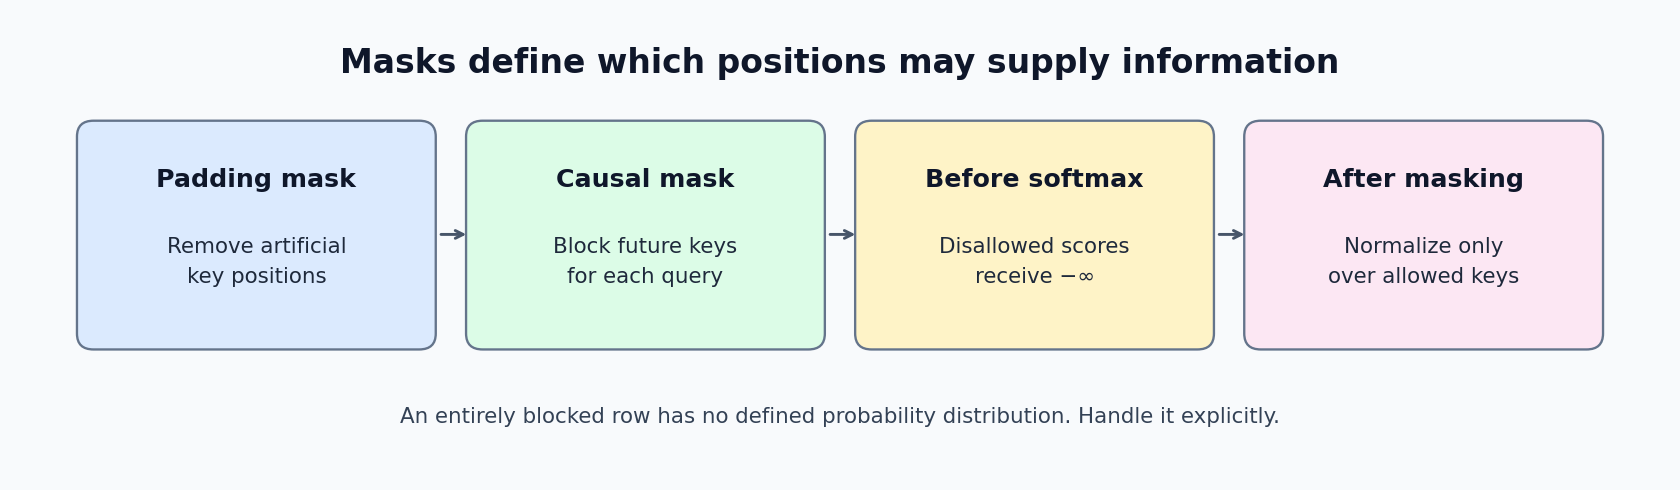

For next-token prediction at a position, later input tokens may reveal the answer. A causal mask allows the current position and earlier positions, while blocking future keys.

| Query position | Key 0 | Key 1 | Key 2 |
| --- | --- | --- | --- |
| 0 | Allow | Block | Block |
| 1 | Allow | Allow | Block |
| 2 | Allow | Allow | Allow |

An additive mask uses zero for allowed scores and $-\infty$ for blocked scores. After softmax, blocked entries receive zero weight. Masking weights after softmax without renormalizing changes the sum and is not the same operation.

In the companion's two-position example, the first causal query has only its own value available, so its output equals that value. Without the mask, the second position contributes to the first query. The difference demonstrates information flow, not improved prediction quality.


## Keep padding and API mask conventions separate

A padding mask marks artificial batch positions. A causal mask encodes which time relationships are allowed. They can be combined, but they solve different problems. Padded query outputs may still be computed; exclude them from the task loss or summary when appropriate.

For Boolean `attn_mask`, PyTorch's functional scaled-dot-product attention treats `True` as allowed. `nn.MultiheadAttention` treats `True` as blocked; its Boolean key-padding mask also marks blocked positions. Check the relevant [functional attention documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html) and [MultiheadAttention documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html) before reusing a mask between APIs.

An all-blocked row has no ordinary softmax distribution. Some implementations handle this specially; others can produce invalid values. Do not rely on unspecified behavior. Ensure real queries have at least one allowed key, or explicitly handle inactive rows.


## Follow a loss gradient back into the attention scores

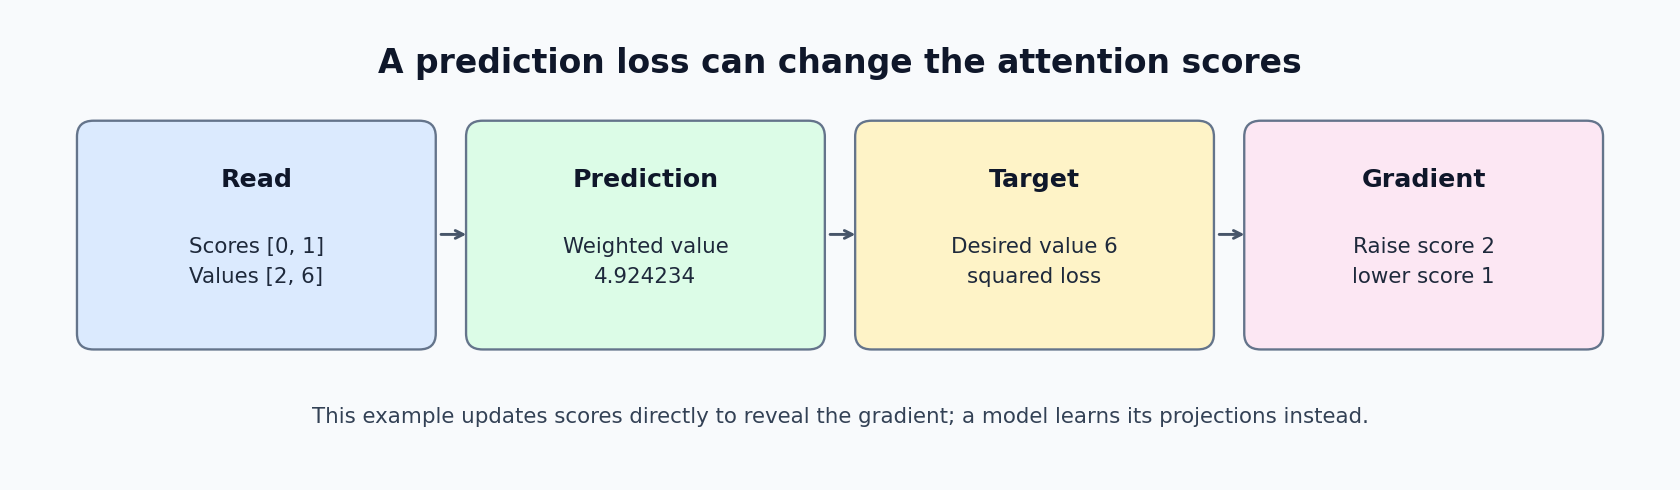

Use the scalar output $o=4.924234$ and target $y=6$. With $L=(o-y)^2$, the loss is approximately 1.157272 and $\partial L/\partial o=2(o-y)\approx-2.151531$.

For a scalar attention read, a useful derivative is:

$$\frac{\partial o}{\partial s_j}=\alpha_j(v_j-o).$$

The score gradients are approximately $\partial L/\partial s_1=1.692067$ and $\partial L/\partial s_2=-1.692067$. With learning rate 0.1, a direct score update moves $[0,1]$ to approximately $[-0.169207,1.169207]$. The second value receives more weight, moving the read toward six.

This treats scores as adjustable quantities to expose the mechanism. In a learned network, scores depend on queries, keys, projection weights, and upstream representations. The value projections also receive gradients. Training changes those parameters rather than storing an independently learned score for every possible token pair.


## Understand what the weights can and cannot explain

An attention weight describes a contribution to this particular value mixture. It is one intermediate quantity within a larger model. Residual paths, multiple heads, nonlinear layers, and later reads can all influence the final prediction.

A heatmap can help inspect which positions a head reads, but it does not automatically establish causal importance or human-like reasoning. A high weight on a position could accompany a value that contributes little useful signal. A low weight can coexist with a large or influential value.

Attention is also not an unlimited external memory. The layer can read only the supplied key/value representations. Truncating the context removes positions unless a separate mechanism stores or retrieves their information. A model can confidently generate a poor answer even when its attention computation is mathematically correct.

Use attention plots to ask questions about computation, and assess prediction quality with task-specific tests and properly held-out examples.


## Measure cost and inspect common failures

For dense attention, each query compares with each key. Score storage is proportional to $BHL_qL_k$ if the full tensor is materialized, where $B$ is batch size and $H$ is head count. Score and value products cost roughly $O(L_qL_kd_k)$ and $O(L_qL_kd_v)$ per head, excluding projections.

| Symptom | First check |
| --- | --- |
| Weights do not sum to one before dropout | Softmax axis or masking |
| Output count follows keys instead of queries | Transpose and matrix dimensions |
| Early predictions change when future tokens change | Causal mask and upstream representations |
| Padding alters summaries | Key mask and query/loss handling |
| Invalid values on short examples | Entirely blocked rows |
| Very peaked weights from the start | Score scale and feature magnitudes |

Efficient kernels can avoid storing a full score matrix, but dense query/key interactions still grow with the position-pair count. More context is useful only if the model can learn to use it under the task's constraints.


## Read the companion as a mechanics check

The companion performs three checks: a scalar read, a scaled vector read compared with a built-in operation, and an unmasked-versus-causal comparison. The selected tensors are small enough to inspect every number.

There is no trained prediction task or validation split in this notebook. Its assertions establish arithmetic and information-flow behavior for these inputs. They do not establish that attention is better than a recurrent summary for a particular dataset.

For a meaningful follow-up experiment, define a target that depends on a permitted earlier event, vary the distance and distractors, train learned projections, and evaluate on independent sequences. Compare against a baseline receiving the same available information. Check mask correctness before interpreting a training score.


## Practice the read and keep the main idea

1. If all allowed scores are equal, what weights result?
2. With equal weights and values $[2,6]$, what is the scalar output?
3. For four queries and seven keys, what shape does the score matrix have?
4. Why should a causal mask be applied before softmax?
5. Does a high attention weight alone prove that a token caused the final decision?

**Answers.** Equal scores give uniform weights across allowed keys. The scalar output is four. The score matrix is $4\times7$. Masking before normalization makes the probability distribution sum to one over the permitted choices. An intermediate weight alone does not establish the cause of a final prediction.

**Remember:** a query compares with keys, normalizes over allowed positions, and reads their values. Projections, axis choices, and masks determine what that read means.

Continue with [Transformers](27_Transformers_Notes.ipynb), where attention becomes part of a repeated block with residual paths and positionwise refinement.


## Connect this lesson to a trained Transformer

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>Complete learning experience.</b> The [lesson 32 code project](32_GPT_and_Autoregressive_Models.ipynb) now trains a small causal Transformer, selects a checkpoint on validation sentences, evaluates excluded sentences, compares with a training-only unigram baseline, and generates continuations.</div>

The project uses 256 unique sentences from a controlled combinatorial grammar, split into 192 training, 32 validation, and 32 test documents before encoding. Familiar words appear across splits, but exact sentences do not. This evaluates new combinations from the same grammar rather than general natural-language competence.

| Earlier lesson | Concrete role in the complete project |
|---|---|
| 26: attention | Each query reads a weighted combination of visible values |
| 27: Transformer | Pre-normalized attention and feed-forward residual updates |
| 28: positions | Learned position vectors distinguish token locations |
| 29: multiple heads | Two attention heads inside a width-32 block |
| 30: encoder/decoder | A causal single-stream backbone, without source cross-attention |
| 31: masked prediction | Contrast: this project predicts next tokens, not hidden tokens using both sides |
| 32: autoregression | Shifted targets, repeated optimization, held-out likelihood, and feedback during generation |

Trace one sentence from BOS through embeddings and positions to `[B,L,V]` logits. Then check which targets are excluded, how validation chooses the stored weights, and why generated tokens become part of the next input. A future-token perturbation assertion verifies causal visibility. Sampling excludes invalid special outputs but does not enforce the sentence grammar.
